### Import all packages need in the cell below

In [2]:
#using Pkg
#Pkg.add("GLPK")
#Pkg.add("JuMP")
#Pkg.add("Ipopt")

using Plots           # para gerar os gráficos
using JuMP            # modelar
using Ipopt           # Variaveis não lineares
using GLPK            # lineares e inteiros
using LinearAlgebra   # operações matriciais
using Statistics      # regressãob

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

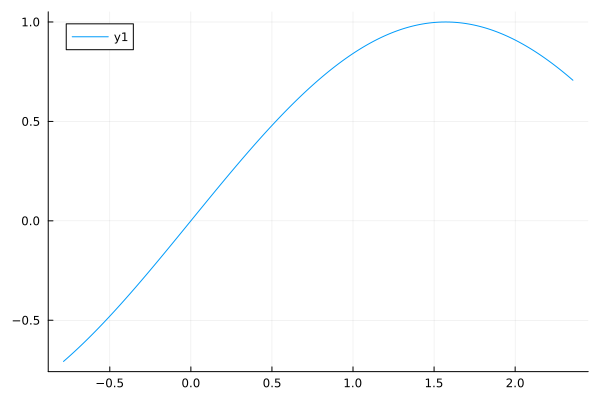

In [ ]:
# definindo os valores de x
x = range(-pi / 4, 3 * pi / 4, length=2000) # criar valores de mesmo espaçamento com 2000 divisões no intervalo

# Calcula sin(x)
y = sin.(x)  # Calcular y em função de X

# Mostra o gráfico
plot(x, y)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

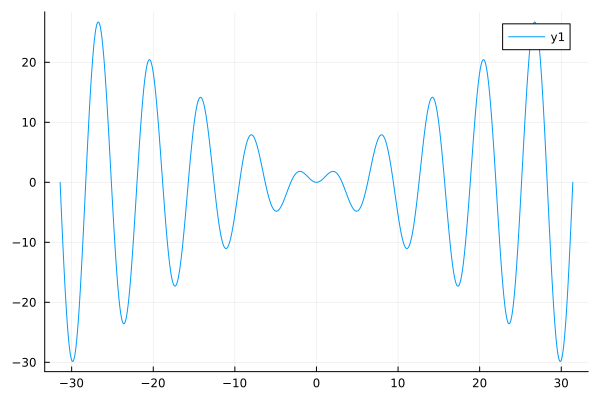

In [ ]:
# Definindo os valores de x
x = range(-10 * pi, 10 * pi, length=1000)

# Calcula x * sin(x)
A = sin.(x)
y = x .* A

# Mostra o gráfico
plot(x, y)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [ ]:
# Entendo que o problema seja: Construir um Tanque Cilindrico Com volume Fixo N=10.
# E para isso Preciso descobrir quais os valores das Variaveis, r=raio, h=altura model tendo como objetivo o menor custo.

# custo Min = 2π*c1*​r*h+2π*c2*​r2
# 2π*r*h = área lateral
# 2π*r*2 = área das duas tampas
# Variaveis r=raio e h=altura
# πr*2*h=N Volume máximo do cilindro N=10

# Dados do problema
N = 10     # Esse Volume é fixo é um dos Condicionantes 
c1 = 2     # Custo da Lateral
c2 = 0.5   # Custo das Tampas

# Cria o modelo
A = Model(Ipopt.Optimizer) # Ipopt porque o problema é não linear

# Variáveis: Objetivo a descobrir no problema.
@variable(A, r >= 0)  #Criar a Variavel r dentro do modelo Ipopt, e também forçar um valor positivo visto que raio negativo não existe
@variable(A, h >= 0)  #Criar a Variavel h dentro do modelo Ipopt, igual para a atura.

# Função objetivo não linear.
@NLobjective(A, Min, 2 * pi * c1 * r * h + 2 * pi * c2 * r^2)    # Com esssa função queremos minimizar o custo

# Restrição não linear
@NLconstraint(A, pi * r^2 * h == N) # esta função cria uma restrição

# Resolve
optimize!(A)

# Mostra os resultados
println("r = ", value(r))
println("h = ", value(h))
println("valor minimo = ", objective_value(A))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.5707932e-03 1.00e+01 8.74e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [ ]:
# o problema é maximizar a área de cobertura do toldo
# necessário descobrir quais os valores das Variaveis
# x = projeção lateral
# y = ângulo de inclinação do toldo
# Área Max=(w+4x)sin(y)
# xcos(y)=h

# code# Dados
h = 2   # Altura do Toldo.
w = 3   # A´rea Central  do Toldo - aqui não considerei o beiral 

# Modelo
Toldo = Model(Ipopt.Optimizer)    #

# Variáveis com chute inicial
@variable(Toldo, x >= 0, start = 1.0)
@variable(Toldo, y >= 0, start = 1.0)

# Função da Área que queremos maximizar
#CE = sin(y)                                  # Coeficiente de inclinação do Toldo
#@NLobjective(Toldo, Max, (w + 2 * x) * CE)   # Função para Máximizar o tamanho do toldo
@NLobjective(Toldo, Min, sqrt(x^2 + y^2))     # Ipopt porque o problema é não linear

# Restrição do problema
#@NLconstraint(Toldo, x * cos(y) == h)
@NLconstraint(Toldo, y - (w * y / x) >= h)

# Resolver
optimize!(Toldo)

# Resultado
println("x = ", value(x))
println("y = ", value(y))
println("valor maximo = ", objective_value(Toldo))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.4142136e+00 4.00e+00 9.49e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [9]:
# problema é colocar a maior figura possível dentro de uma região limitada.
# área máxima do  retangulo x2+y2≤1
# escolher x
# escolher y
# maximizar a área sem sair da região permitida

# Cria o modelo
model = Model(Ipopt.Optimizer)

# Variáveis
@variable(model, x >= 0, start = 1)
@variable(model, y >= 0, start = 1)

# Função objetivo: maximizar a área
@NLobjective(model, Max, 4 * x * y)

# Restrição
@NLconstraint(model, x^2 + y^2 <= 1)

# Resolve
optimize!(model)

# Mostra os resultados
println("x = ", value(x))
println("y = ", value(y))
println("area maxima = ", objective_value(model))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        5

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.0000000e+00 1.00e+00 1.33e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

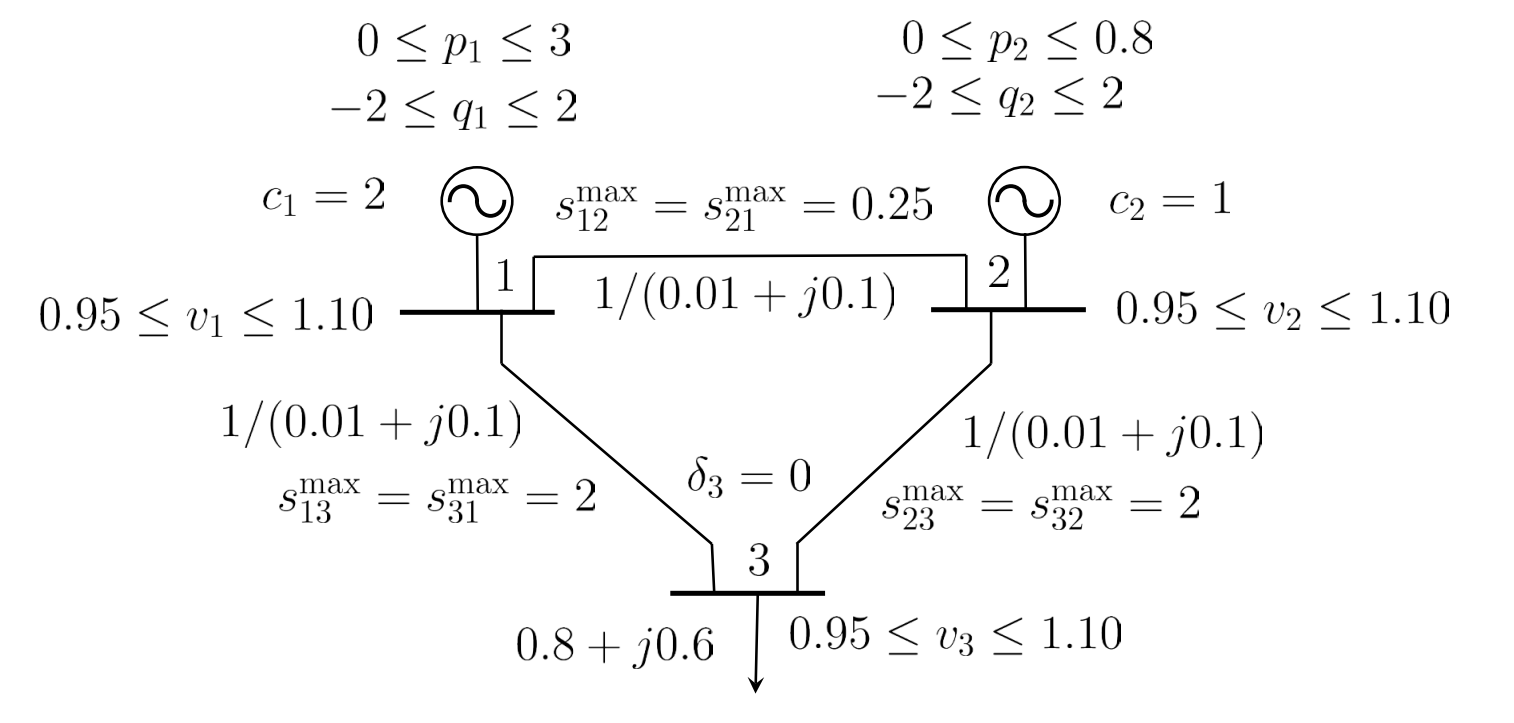

In [ ]:
#O que representam as variáveis principais:
#p1, p2 São as potências ativas geradas nas barras 1 e 2.
#q1, q2 São as potências reativas geradas nas barras 1 e 2.
#v1, v2, v3 São os módulos de tensão nas três barras.
#d1, d2, d3 São os ângulos das tensões nas barras.
#Pd3 potência ativa Cosumida na barra 3.
#Qd3 potência reativa Cosumida na barra 3.


# Dados do problema
Pd3 = 0.8
Qd3 = 0.6

c1 = 2.0
c2 = 1.0

z = 0.01 + 0.1im        #impedância da linha
y = 1 / z               #admitância da linha

g = real(y)             #condutância
b = imag(y)             #susceptância

# Cria o modelo
model = Model(Ipopt.Optimizer) 
set_silent(model)

# Variáveis de geração
@variable(model, 0 <= p1 <= 3)
@variable(model, 0 <= p2 <= 0.8)
@variable(model, -2 <= q1 <= 2)
@variable(model, -2 <= q2 <= 2)

# Variáveis de tensão
@variable(model, 0.95 <= v1 <= 1.10, start = 1.0)
@variable(model, 0.95 <= v2 <= 1.10, start = 1.0)
@variable(model, 0.95 <= v3 <= 1.10, start = 1.0)

# Ângulos
@variable(model, d1, start = 0.0)
@variable(model, d2, start = 0.0)
@variable(model, d3 == 0)              #Barra de Referencia

# Função objetivo: minimizar custo de geração
@objective(model, Min, c1*p1 + c2*p2)

# Equações de balanço de potência ativa
@NLconstraint(model,
    p1 == v1^2*(2g) +
          v1*v2*(-g*cos(d1-d2) - b*sin(d1-d2)) +
          v1*v3*(-g*cos(d1-d3) - b*sin(d1-d3))
)

@NLconstraint(model,
    p2 == v2^2*(2g) +
          v2*v1*(-g*cos(d2-d1) - b*sin(d2-d1)) +
          v2*v3*(-g*cos(d2-d3) - b*sin(d2-d3))
)

@NLconstraint(model,
    -Pd3 == v3^2*(2g) +
            v3*v1*(-g*cos(d3-d1) - b*sin(d3-d1)) +
            v3*v2*(-g*cos(d3-d2) - b*sin(d3-d2))
)

# Equações de balanço de potência reativa
@NLconstraint(model,
    q1 == -v1^2*(2b) +
          v1*v2*(-g*sin(d1-d2) + b*cos(d1-d2)) +
          v1*v3*(-g*sin(d1-d3) + b*cos(d1-d3))
)

@NLconstraint(model,
    q2 == -v2^2*(2b) +
          v2*v1*(-g*sin(d2-d1) + b*cos(d2-d1)) +
          v2*v3*(-g*sin(d2-d3) + b*cos(d2-d3))
)

@NLconstraint(model,
    -Qd3 == -v3^2*(2b) +
             v3*v1*(-g*sin(d3-d1) + b*cos(d3-d1)) +
             v3*v2*(-g*sin(d3-d2) + b*cos(d3-d2))
)

# Fluxos de potência nas linhas
# Linha 1 -> 2
@NLexpression(model, P12, g*v1^2 - v1*v2*(g*cos(d1-d2) + b*sin(d1-d2)))
@NLexpression(model, Q12, -b*v1^2 - v1*v2*(g*sin(d1-d2) - b*cos(d1-d2)))

# Linha 2 -> 1
@NLexpression(model, P21, g*v2^2 - v2*v1*(g*cos(d2-d1) + b*sin(d2-d1)))
@NLexpression(model, Q21, -b*v2^2 - v2*v1*(g*sin(d2-d1) - b*cos(d2-d1)))

# Linha 1 -> 3
@NLexpression(model, P13, g*v1^2 - v1*v3*(g*cos(d1-d3) + b*sin(d1-d3)))
@NLexpression(model, Q13, -b*v1^2 - v1*v3*(g*sin(d1-d3) - b*cos(d1-d3)))

# Linha 3 -> 1
@NLexpression(model, P31, g*v3^2 - v3*v1*(g*cos(d3-d1) + b*sin(d3-d1)))
@NLexpression(model, Q31, -b*v3^2 - v3*v1*(g*sin(d3-d1) - b*cos(d3-d1)))

# Linha 2 -> 3
@NLexpression(model, P23, g*v2^2 - v2*v3*(g*cos(d2-d3) + b*sin(d2-d3)))
@NLexpression(model, Q23, -b*v2^2 - v2*v3*(g*sin(d2-d3) - b*cos(d2-d3)))

# Linha 3 -> 2
@NLexpression(model, P32, g*v3^2 - v3*v2*(g*cos(d3-d2) + b*sin(d3-d2)))
@NLexpression(model, Q32, -b*v3^2 - v3*v2*(g*sin(d3-d2) - b*cos(d3-d2)))

# Limites de fluxo aparente
@NLconstraint(model, P12^2 + Q12^2 <= 0.25^2)
@NLconstraint(model, P21^2 + Q21^2 <= 0.25^2)

@NLconstraint(model, P13^2 + Q13^2 <= 2^2)
@NLconstraint(model, P31^2 + Q31^2 <= 2^2)

@NLconstraint(model, P23^2 + Q23^2 <= 2^2)
@NLconstraint(model, P32^2 + Q32^2 <= 2^2)

# Resolve
optimize!(model)

# Resultados
println("Status = ", termination_status(model))
println("Valor objetivo = ", objective_value(model))

println("p1 = ", value(p1))
println("p2 = ", value(p2))
println("q1 = ", value(q1))
println("q2 = ", value(q2))

println("v1 = ", value(v1))
println("v2 = ", value(v2))
println("v3 = ", value(v3))

println("d1 = ", value(d1))
println("d2 = ", value(d2))
println("d3 = ", value(d3))

Status = LOCALLY_SOLVED
Valor objetivo = 0.8360786945615203
p1 = 0.03090683455326139
p2 = 0.7742650254549975
q1 = 0.32091669238596826
q2 = 0.33080190769662426
v1 = 1.0977001927052659
v2 = 1.099999893829516
v3 = 1.0663591316422778
d1 = 0.021231966882032213
d2 = 0.041912659955651445
d3 = 0.0


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [13]:
# Tabela com as 3 variáveis
X = [
    1.0  0.5  1.2
    2.0  1.0  2.1
    3.0  1.5  2.9
    4.0  2.0  3.8
    5.0  2.5  4.5
]

# Valores de saída
y = [2.0, 3.9, 6.1, 8.0, 9.8]

# Coloca uma coluna de 1 para o termo constante
A = hcat(ones(size(X,1)), X)

# Calcula os coeficientes da regressão
beta = A \ y

# Mostra o resultado
println("b0 = ", beta[1])
println("b1 = ", beta[2])
println("b2 = ", beta[3])
println("b3 = ", beta[4])

b0 = -0.28545454545453774
b1 = 1.0327272727272836
b2 = 0.5163636363636416
b3 = 0.8181818181818014


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |





|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [18]:
# code# Pontuações dos designers em cada projeto
score = [
    90 80 10 50
    60 70 50 65
    70 40 80 85
]

# Horas necessárias por projeto
required = [70, 50, 85, 35]

# Horas disponíveis por designer
available = [80, 80, 80]

# Número de designers e projetos
m = 3
n = 4

# Cria o modelo
model = Model(GLPK.Optimizer)

# Variáveis: horas que cada designer dedica a cada projeto
@variable(model, x[1:m, 1:n] >= 0)

# Função objetivo: maximizar a pontuação total
@objective(model, Max, sum(score[i,j] * x[i,j] for i in 1:m, j in 1:n))

# Restrição: cada designer pode trabalhar no máximo 80 horas
@constraint(model, [i in 1:m], sum(x[i,j] for j in 1:n) <= available[i])

# Restrição: cada projeto deve receber exatamente as horas necessárias
@constraint(model, [j in 1:n], sum(x[i,j] for i in 1:m) == required[j])

# Resolve o problema
optimize!(model)

# Mostra o valor ótimo
println("Valor ótimo = ", objective_value(model))

# Mostra as horas alocadas
for i in 1:m
    for j in 1:n
        println("x[$i,$j] = ", value(x[i,j]))
    end
end

Valor ótimo = 18825.0
x[1,1] = 70.0
x[1,2] = 10.0
x[1,3] = 0.0
x[1,4] = 0.0
x[2,1] = 0.0
x[2,2] = 40.0
x[2,3] = 5.0
x[2,4] = 35.0
x[3,1] = 0.0
x[3,2] = 0.0
x[3,3] = 80.0
x[3,4] = 0.0


# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [21]:
# Dados do problema
cost = [1.0, 0.5, 2.0, 0.3]
calories = [100, 200, 150, 70]
protein = [0.5, 4, 8, 6]
vitamins = [2, 0, 10, 0]

# Cria o modelo
model = Model(GLPK.Optimizer)

# Variáveis: quantidade de cada alimento
@variable(model, x[1:4] >= 0)

# Função objetivo: minimizar o custo total
@objective(model, Min, sum(cost[i] * x[i] for i in 1:4))

# Restrições nutricionais
@constraint(model, sum(calories[i] * x[i] for i in 1:4) >= 500)
@constraint(model, sum(protein[i] * x[i] for i in 1:4) >= 50)
@constraint(model, sum(vitamins[i] * x[i] for i in 1:4) >= 100)

# Resolve o problema
optimize!(model)

# Guarda os resultados
result = [value(x[i]) for i in 1:4]
foods = ["Apple", "Bread", "Milk", "Egg"]

# Mostra as quantidades escolhidas
println("Optimal food quantities:")
for i in 1:4
    println(foods[i], ": ", result[i])
end

# Calcula totais
total_cost = objective_value(model)
total_calories = sum(calories[i] * result[i] for i in 1:4)
total_protein = sum(protein[i] * result[i] for i in 1:4)
total_vitamins = sum(vitamins[i] * result[i] for i in 1:4)

println("\nNutrition summary:")
println("Calories = ", total_calories)
println("Protein = ", total_protein)
println("Vitamins = ", total_vitamins)

println("\nMinimum cost = ", total_cost)

Optimal food quantities:
Apple: 0.0
Bread: 0.0
Milk: 10.0
Egg: 0.0

Nutrition summary:
Calories = 1500.0
Protein = 80.0
Vitamins = 100.0

Minimum cost = 20.0


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [28]:
# Valores dos itens
item_values = [60, 40, 50]

# Pesos dos itens
weights = [2, 1, 1]

# Capacidade da mochila
capacity = 3.5

# Nomes dos itens
items = ["Tent", "Stove", "Food"]

# Cria o modelo
model = Model(GLPK.Optimizer)

# Variáveis binárias
@variable(model, x[1:3], Bin)

# Função objetivo
@objective(model, Max, sum(item_values[i] * x[i] for i in 1:3))

# Restrição de peso
@constraint(model, sum(weights[i] * x[i] for i in 1:3) <= capacity)

# Resolve
optimize!(model)

# Guarda o resultado das variáveis
result = [JuMP.value(x[i]) for i in 1:3]

# Mostra os resultados
println("Selected items:")
for i in 1:3
    println(items[i], ": ", result[i])
end

println("\nTotal value = ", objective_value(model))
println("Total weight = ", sum(weights[i] * result[i] for i in 1:3))

Selected items:
Tent: 1.0
Stove: 0.0
Food: 1.0

Total value = 110.0
Total weight = 3.0
